***Load INFO***

In [ ]:
import os, pickle, random, math
import numpy as np
import pandas as pd

import torch
from torch.utils.data import Dataset, DataLoader

# Kaggle path
DATA_ROOT = "/content/drive/MyDrive/ML_Medicine/data"
TRAIN_PKL = os.path.join(DATA_ROOT, "lung_cancer_train.pkl")
TEST_PKL  = os.path.join(DATA_ROOT, "lung_cancer_test.pkl")

print("TRAIN_PKL:", TRAIN_PKL, "exists:", os.path.exists(TRAIN_PKL))
print("TEST_PKL :", TEST_PKL,  "exists:", os.path.exists(TEST_PKL))


In [39]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
import os
import pickle
import numpy as np
import pandas as pd

def load_pkl_robust(path: str):
    """
    Robust loader for legacy pandas pickles.
    Order:
      1) pandas.read_pickle (fast path)
      2) pandas.compat.pickle_compat.load (often fixes old pandas internals)
      3) pickle.load with latin1 encoding (fallback)
    """
    assert os.path.exists(path), f"File not found: {path}"

    # 1) pandas.read_pickle
    try:
        obj = pd.read_pickle(path)
        return obj
    except Exception as e1:
        print(f"[WARN] pd.read_pickle failed: {type(e1).__name__}: {e1}")

    # 2) pandas pickle_compat
    try:
        import pandas.compat.pickle_compat as pc
        with open(path, "rb") as f:
            obj = pc.load(f)
        return obj
    except Exception as e2:
        print(f"[WARN] pandas.compat.pickle_compat.load failed: {type(e2).__name__}: {e2}")

    # 3) raw pickle fallback
    try:
        with open(path, "rb") as f:
            obj = pickle.load(f, encoding="latin1")
        return obj
    except Exception as e3:
        raise RuntimeError(
            "All loading methods failed.\n"
            f"- pd.read_pickle error: {e1}\n"
            f"- pickle_compat error: {e2}\n"
            f"- pickle latin1 error: {e3}\n"
            "Next best fix: convert in a Python 3.10 env (micromamba) to Parquet once."
        )

#  Load 
train_df = load_pkl_robust(TRAIN_PKL)
test_df  = load_pkl_robust(TEST_PKL)

# Basic checks 
print("train_df type:", type(train_df), "len:", len(train_df))
print("test_df  type:", type(test_df),  "len:", len(test_df))

# Some pickles may load as dict-like; normalize to DataFrame if needed
if not hasattr(train_df, "columns") and isinstance(train_df, dict):
    train_df = pd.DataFrame(train_df)
if not hasattr(test_df, "columns") and isinstance(test_df, dict):
    test_df = pd.DataFrame(test_df)

print("Columns:", list(train_df.columns))

#  Sample inspect 
s0 = train_df.iloc[0]
print("hu_array_old shape:", np.array(s0["hu_array_old"]).shape)
print("hu_array     shape:", np.array(s0["hu_array"]).shape)
print("mask         shape:", np.array(s0["mask"]).shape)
print("mask unique:", np.unique(s0["mask"]))
print("mask pos pixels:", int(np.sum(s0["mask"])))
print("HU range:", float(np.min(s0["hu_array_old"])), float(np.max(s0["hu_array_old"])))



***Check size node***

In [ ]:
import numpy as np

def fast_mask_to_bbox(mask):
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return None
    x1, x2 = xs.min(), xs.max() + 1
    y1, y2 = ys.min(), ys.max() + 1
    return x1, y1, x2, y2

ws, hs, areas, has_obj = [], [], [], 0

for i in range(len(train_df)):
    m = np.array(train_df.iloc[i]["mask"])
    bb = fast_mask_to_bbox(m)
    if bb is None:
        continue
    has_obj += 1
    x1,y1,x2,y2 = bb
    w, h = x2-x1, y2-y1
    ws.append(w); hs.append(h); areas.append(w*h)

ws = np.array(ws); hs = np.array(hs); areas = np.array(areas)

print("Images with tumor:", has_obj, "/", len(train_df))
if has_obj > 0:
    for name, arr in [("w",ws),("h",hs),("area",areas)]:
        print(f"{name}: min={arr.min()}  p25={np.percentile(arr,25):.1f}  "
              f"p50={np.percentile(arr,50):.1f}  p75={np.percentile(arr,75):.1f}  "
              f"p90={np.percentile(arr,90):.1f}  max={arr.max()}")


In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

def window_hu(hu, center=-600, width=1500):
    low = center - width/2
    high = center + width/2
    hu = np.clip(hu, low, high)
    hu = (hu - low) / (high - low + 1e-8)
    return (hu * 255).astype(np.uint8)

def mask_union_bbox(mask, min_area=5):
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return np.zeros((0,4), dtype=np.float32)
    x1, x2 = xs.min(), xs.max()+1
    y1, y2 = ys.min(), ys.max()+1
    if (x2-x1)*(y2-y1) < min_area:
        return np.zeros((0,4), dtype=np.float32)
    return np.array([[x1,y1,x2,y2]], dtype=np.float32)

class LungFRCNNDataset(Dataset):
    def __init__(self, df, use_lung_only=True, center=-600, width=1500):
        self.df = df.reset_index(drop=True)
        self.use_lung_only = use_lung_only
        self.center = center
        self.width = width

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        hu = np.array(row["hu_array"] if self.use_lung_only else row["hu_array_old"])
        mask = np.array(row["mask"]).astype(np.uint8)

        img = window_hu(hu, self.center, self.width)          # (H,W) uint8
        img = np.stack([img, img, img], axis=0)               # (3,H,W)
        img = torch.from_numpy(img).float() / 255.0           # float32 [0,1]

        boxes = mask_union_bbox(mask, min_area=5)             # (N,4)
        labels = np.ones((boxes.shape[0],), dtype=np.int64)   # 1=nodule

        target = {
            "boxes": torch.from_numpy(boxes),      # float32
            "labels": torch.from_numpy(labels),    # int64
        }
        return img, target

def collate_fn(batch):
    images, targets = zip(*batch)
    return list(images), list(targets)


In [ ]:
import random

idxs = list(range(len(train_df)))
random.seed(42)
random.shuffle(idxs)

val_ratio = 0.2
n_val = int(len(idxs)*val_ratio)
val_ids = idxs[:n_val]
trn_ids = idxs[n_val:]

trn_df = train_df.iloc[trn_ids].reset_index(drop=True)
val_df = train_df.iloc[val_ids].reset_index(drop=True)

train_ds = LungFRCNNDataset(trn_df, use_lung_only=True)
val_ds   = LungFRCNNDataset(val_df, use_lung_only=True)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=2, collate_fn=collate_fn)
val_loader   = DataLoader(val_ds, batch_size=4, shuffle=False, num_workers=2, collate_fn=collate_fn)

images, targets = next(iter(train_loader))
print("batch images:", len(images), images[0].shape, images[0].dtype)
print("boxes shape:", targets[0]["boxes"].shape, "labels:", targets[0]["labels"])


***Box utilities (IoU, encode/decode)***

In [ ]:
import torch

def box_iou(boxes1, boxes2):
    """
    boxes: (N,4) xyxy
    returns IoU: (N,M)
    """
    if boxes1.numel() == 0 or boxes2.numel() == 0:
        return torch.zeros((boxes1.shape[0], boxes2.shape[0]), device=boxes1.device)

    area1 = (boxes1[:,2]-boxes1[:,0]).clamp(min=0) * (boxes1[:,3]-boxes1[:,1]).clamp(min=0)
    area2 = (boxes2[:,2]-boxes2[:,0]).clamp(min=0) * (boxes2[:,3]-boxes2[:,1]).clamp(min=0)

    lt = torch.max(boxes1[:,None,:2], boxes2[None,:,:2])   # (N,M,2)
    rb = torch.min(boxes1[:,None,2:], boxes2[None,:,2:])   # (N,M,2)
    wh = (rb - lt).clamp(min=0)
    inter = wh[:,:,0] * wh[:,:,1]
    union = area1[:,None] + area2[None,:] - inter + 1e-8
    return inter / union

def encode_boxes(anchors, gt):
    """
    anchors: (N,4) xyxy
    gt:      (N,4) xyxy matched gt
    return deltas: (N,4) [dx,dy,dw,dh]
    """
    ax1, ay1, ax2, ay2 = anchors.unbind(dim=1)
    gx1, gy1, gx2, gy2 = gt.unbind(dim=1)

    aw = (ax2-ax1).clamp(min=1e-6)
    ah = (ay2-ay1).clamp(min=1e-6)
    acx = ax1 + 0.5*aw
    acy = ay1 + 0.5*ah

    gw = (gx2-gx1).clamp(min=1e-6)
    gh = (gy2-gy1).clamp(min=1e-6)
    gcx = gx1 + 0.5*gw
    gcy = gy1 + 0.5*gh

    dx = (gcx - acx) / aw
    dy = (gcy - acy) / ah
    dw = torch.log(gw / aw)
    dh = torch.log(gh / ah)

    return torch.stack([dx, dy, dw, dh], dim=1)

def decode_boxes(anchors, deltas):
    """
    anchors: (N,4)
    deltas:  (N,4)
    returns boxes: (N,4)
    """
    ax1, ay1, ax2, ay2 = anchors.unbind(dim=1)
    aw = (ax2-ax1).clamp(min=1e-6)
    ah = (ay2-ay1).clamp(min=1e-6)
    acx = ax1 + 0.5*aw
    acy = ay1 + 0.5*ah

    dx, dy, dw, dh = deltas.unbind(dim=1)
    gcx = acx + dx * aw
    gcy = acy + dy * ah
    gw = aw * torch.exp(dw).clamp(max=10.0)
    gh = ah * torch.exp(dh).clamp(max=10.0)

    x1 = gcx - 0.5*gw
    y1 = gcy - 0.5*gh
    x2 = gcx + 0.5*gw
    y2 = gcy + 0.5*gh
    return torch.stack([x1,y1,x2,y2], dim=1)

def clip_boxes_to_image(boxes, H, W):
    boxes[:,0].clamp_(0, W)
    boxes[:,2].clamp_(0, W)
    boxes[:,1].clamp_(0, H)
    boxes[:,3].clamp_(0, H)
    return boxes

***Anchor generator***

In [ ]:
import math
import torch

def generate_base_anchors(scales, ratios, device="cpu"):
    """
    scales: list of sizes (pixels) e.g. [8,12,16,24,32,40,56,72]
    ratios: list of aspect ratios (h/w) e.g. [0.5,1.0,2.0]
    returns: (A,4) anchors centered at (0,0) in xyxy
    """
    anchors = []
    for s in scales:
        area = s * s
        for r in ratios:
            w = math.sqrt(area / r)
            h = w * r
            x1 = -0.5*w; y1 = -0.5*h
            x2 =  0.5*w; y2 =  0.5*h
            anchors.append([x1,y1,x2,y2])
    return torch.tensor(anchors, dtype=torch.float32, device=device)

def grid_anchors(feat_h, feat_w, stride, base_anchors):
    """
    place base anchors on feature grid centers
    base_anchors: (A,4) centered at 0
    returns all_anchors: (feat_h*feat_w*A, 4)
    """
    device = base_anchors.device
    shifts_x = (torch.arange(feat_w, device=device) + 0.5) * stride
    shifts_y = (torch.arange(feat_h, device=device) + 0.5) * stride
    shift_y, shift_x = torch.meshgrid(shifts_y, shifts_x, indexing="ij")
    shifts = torch.stack([shift_x, shift_y, shift_x, shift_y], dim=-1)  # (Hf,Wf,4)
    shifts = shifts.reshape(-1,4)  # (Hf*Wf,4)

    A = base_anchors.shape[0]
    K = shifts.shape[0]
    anchors = base_anchors.reshape(1,A,4) + shifts.reshape(K,1,4)
    return anchors.reshape(K*A,4)

# tuned to your bbox stats
ANCHOR_SCALES = [8, 12, 16, 24, 32, 40, 56, 72]
ANCHOR_RATIOS = [0.5, 1.0, 2.0]
STRIDE = 8

***NMS (pure PyTorch, no torchvision)***

In [ ]:
def nms(boxes, scores, iou_thresh=0.5):
    """
    boxes: (N,4) xyxy
    scores: (N,)
    returns keep indices
    """
    if boxes.numel() == 0:
        return torch.zeros((0,), dtype=torch.long, device=boxes.device)

    x1 = boxes[:,0]; y1 = boxes[:,1]; x2 = boxes[:,2]; y2 = boxes[:,3]
    areas = (x2-x1).clamp(min=0) * (y2-y1).clamp(min=0)
    order = scores.argsort(descending=True)

    keep = []
    while order.numel() > 0:
        i = order[0].item()
        keep.append(i)
        if order.numel() == 1:
            break
        rest = order[1:]

        xx1 = torch.maximum(x1[i], x1[rest])
        yy1 = torch.maximum(y1[i], y1[rest])
        xx2 = torch.minimum(x2[i], x2[rest])
        yy2 = torch.minimum(y2[i], y2[rest])

        w = (xx2-xx1).clamp(min=0)
        h = (yy2-yy1).clamp(min=0)
        inter = w*h
        iou = inter / (areas[i] + areas[rest] - inter + 1e-8)

        order = rest[iou <= iou_thresh]

    return torch.tensor(keep, dtype=torch.long, device=boxes.device)

***RPN Head + Matching + Loss + Proposals***

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleBackbone(nn.Module):
    """
    Deeper Backbone with residual connections, stride=8.
    Input: (B,3,512,512)
    Output: feat (B,256,64,64) if stride=8
    """
    def __init__(self, in_ch=3, c=256):
        super().__init__()
        # Block 1: stride 2 -> 256x256
        self.conv1 = nn.Conv2d(in_ch, 64, 3, stride=2, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        # Block 2: stride 2 -> 128x128
        self.conv2 = nn.Conv2d(64, 128, 3, stride=2, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        # Block 3: stride 2 -> 64x64
        self.conv3 = nn.Conv2d(128, 256, 3, stride=2, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        # Block 4: stride 1, residual
        self.conv4 = nn.Conv2d(256, 256, 3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        # Block 5: stride 1, residual
        self.conv5 = nn.Conv2d(256, c, 3, stride=1, padding=1)
        self.bn5 = nn.BatchNorm2d(c)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        identity = x
        x = F.relu(self.bn4(self.conv4(x)))
        x = F.relu(self.bn5(self.conv5(x))) + identity  # residual
        return x

class RPNHead(nn.Module):
    def __init__(self, in_channels, num_anchors):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, in_channels, 3, padding=1)
        self.obj  = nn.Conv2d(in_channels, num_anchors, 1)
        self.reg  = nn.Conv2d(in_channels, num_anchors*4, 1)

    def forward(self, feat):
        t = F.relu(self.conv(feat))
        obj_logits = self.obj(t)               # (B,A,Hf,Wf)
        bbox_deltas = self.reg(t)              # (B,4A,Hf,Wf)
        return obj_logits, bbox_deltas

def match_anchors(anchors, gt_boxes, pos_iou=0.5, neg_iou=0.1):
    """
    anchors: (N,4)
    gt_boxes: (M,4)
    returns:
      labels: (N,) {1 pos, 0 neg, -1 ignore}
      matched_gt: (N,4) (dummy for neg/ignore)
    """
    device = anchors.device
    N = anchors.shape[0]
    labels = torch.full((N,), -1, dtype=torch.int64, device=device)
    matched_gt = torch.zeros((N,4), dtype=torch.float32, device=device)

    if gt_boxes.numel() == 0:
        labels[:] = 0
        return labels, matched_gt

    ious = box_iou(anchors, gt_boxes)          # (N,M)
    max_iou, argmax = ious.max(dim=1)          # (N,)

    labels[max_iou < neg_iou] = 0
    labels[max_iou >= pos_iou] = 1

    matched_gt = gt_boxes[argmax]
    return labels, matched_gt

def rpn_loss(obj_logits, bbox_deltas, anchors, targets, feat_hw, num_anchors,
             pos_iou=0.5, neg_iou=0.1, batch_anchors=256, pos_fraction=0.5):
    """
    obj_logits: (B,A,Hf,Wf)
    bbox_deltas: (B,4A,Hf,Wf)
    anchors: (Hf*Wf*A,4)
    targets: list of dict (boxes)
    """
    B, A, Hf, Wf = obj_logits.shape
    assert A == num_anchors

    obj_logits = obj_logits.permute(0,2,3,1).reshape(B, -1)            # (B, N)
    bbox_deltas = bbox_deltas.permute(0,2,3,1).reshape(B, -1, 4)       # (B, N, 4)

    total_obj = 0.0
    total_reg = 0.0

    for b in range(B):
        gt = targets[b]["boxes"].to(anchors.device).float()

        labels, matched_gt = match_anchors(anchors, gt, pos_iou, neg_iou)

        # sample anchors to avoid imbalance
        pos_idx = torch.where(labels == 1)[0]
        neg_idx = torch.where(labels == 0)[0]

        num_pos = int(batch_anchors * pos_fraction)
        num_pos = min(num_pos, pos_idx.numel())
        num_neg = batch_anchors - num_pos
        num_neg = min(num_neg, neg_idx.numel())

        if num_pos > 0:
            pos_idx = pos_idx[torch.randperm(pos_idx.numel(), device=anchors.device)[:num_pos]]
        if num_neg > 0:
            neg_idx = neg_idx[torch.randperm(neg_idx.numel(), device=anchors.device)[:num_neg]]

        keep = torch.cat([pos_idx, neg_idx], dim=0)
        tgt_obj = torch.zeros((keep.numel(),), device=anchors.device)
        tgt_obj[:num_pos] = 1.0

        pred_obj = obj_logits[b, keep]
        obj = F.binary_cross_entropy_with_logits(pred_obj, tgt_obj)

        total_obj += obj

        if num_pos > 0:
            a_pos = anchors[pos_idx]
            gt_pos = matched_gt[pos_idx]
            tgt_d = encode_boxes(a_pos, gt_pos)
            pred_d = bbox_deltas[b, pos_idx]
            reg = F.smooth_l1_loss(pred_d, tgt_d)
            total_reg += reg
        else:
            total_reg += 0.0

    return total_obj / B, total_reg / B

@torch.no_grad()
def rpn_proposals(obj_logits, bbox_deltas, anchors, img_hw, num_anchors,
                  pre_nms_topk=2000, post_nms_topk=400, nms_thresh=0.5, score_thresh=0.05):
    """
    Generate proposals per image
    """
    B, A, Hf, Wf = obj_logits.shape
    obj = torch.sigmoid(obj_logits).permute(0,2,3,1).reshape(B, -1)          # (B,N)
    deltas = bbox_deltas.permute(0,2,3,1).reshape(B, -1, 4)

    H, W = img_hw
    out = []
    for b in range(B):
        scores = obj[b]
        # topk before nms
        k = min(pre_nms_topk, scores.numel())
        vals, idx = scores.topk(k)
        sel_scores = vals
        sel_anchors = anchors[idx]
        sel_deltas = deltas[b, idx]

        boxes = decode_boxes(sel_anchors, sel_deltas)
        boxes = clip_boxes_to_image(boxes, H, W)

        keep = torch.where(sel_scores >= score_thresh)[0]
        boxes = boxes[keep]
        sc = sel_scores[keep]

        keep2 = nms(boxes, sc, iou_thresh=nms_thresh)
        keep2 = keep2[:post_nms_topk]
        out.append(boxes[keep2])
    return out

***Sanity run: Backbone + RPN forward + loss (1 batch)***

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

base_anchors = generate_base_anchors(ANCHOR_SCALES, ANCHOR_RATIOS, device=device)

# grab one batch
images, targets = next(iter(train_loader))
images = torch.stack(images).to(device)  # (B,3,512,512)

backbone = SimpleBackbone(in_ch=3, c=256).to(device)
feat = backbone(images)
B,C,Hf,Wf = feat.shape
print("feat shape:", feat.shape)

anchors = grid_anchors(Hf, Wf, STRIDE, base_anchors)  # (Hf*Wf*A, 4)
num_anchors = base_anchors.shape[0]
print("anchors:", anchors.shape, "A=", num_anchors)

rpn = RPNHead(in_channels=C, num_anchors=num_anchors).to(device)
obj_logits, bbox_deltas = rpn(feat)

obj_l, reg_l = rpn_loss(obj_logits, bbox_deltas, anchors, targets, (Hf,Wf), num_anchors)
print("RPN obj loss:", float(obj_l), "RPN reg loss:", float(reg_l))

props = rpn_proposals(obj_logits, bbox_deltas, anchors, img_hw=(512,512), num_anchors=num_anchors)
print("proposals per image:", [p.shape[0] for p in props])

***ROI Pool***

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def roi_pool_grid(feat, boxes, out_size=7, spatial_scale=1/8):
    """
    feat: (C,Hf,Wf)
    boxes: (N,4) in image coords (xyxy)
    returns: (N,C,out_size,out_size)
    """
    C, Hf, Wf = feat.shape
    device = feat.device
    if boxes.numel() == 0:
        return torch.zeros((0, C, out_size, out_size), device=device)

    # convert to feature coords
    b = boxes.clone()
    b = b * spatial_scale  # scale to feat space
    # clamp
    b[:,0].clamp_(0, Wf-1); b[:,2].clamp_(0, Wf-1)
    b[:,1].clamp_(0, Hf-1); b[:,3].clamp_(0, Hf-1)

    rois = []
    for i in range(b.shape[0]):
        x1,y1,x2,y2 = b[i]
        # avoid degenerate
        if (x2-x1) < 1: x2 = x1 + 1
        if (y2-y1) < 1: y2 = y1 + 1

        xs = torch.linspace(x1, x2, out_size, device=device)
        ys = torch.linspace(y1, y2, out_size, device=device)
        gy, gx = torch.meshgrid(ys, xs, indexing="ij")

        # normalize to [-1,1] for grid_sample
        grid_x = (gx / (Wf-1)) * 2 - 1
        grid_y = (gy / (Hf-1)) * 2 - 1
        grid = torch.stack([grid_x, grid_y], dim=-1).unsqueeze(0)  # (1, S, S, 2)

        patch = F.grid_sample(
            feat.unsqueeze(0), grid, mode="bilinear",
            padding_mode="zeros", align_corners=True
        )  # (1,C,S,S)
        rois.append(patch.squeeze(0))

    return torch.stack(rois, dim=0)

class ROIHead(nn.Module):
    def __init__(self, in_channels=256, pool=7, hidden=256, num_classes=2):
        super().__init__()
        self.pool = pool
        # Two conv layers to retain spatial context
        self.conv1 = nn.Conv2d(in_channels, in_channels, 3, padding=1)
        self.conv2 = nn.Conv2d(in_channels, in_channels, 3, padding=1)
        self.fc1 = nn.Linear(in_channels*pool*pool, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.cls = nn.Linear(hidden, num_classes)  # bg + nodule
        self.reg = nn.Linear(hidden, 4)            # class-agnostic bbox

    def forward(self, roi_feats):
        x = F.relu(self.conv1(roi_feats))
        x = F.relu(self.conv2(x))
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        logits = self.cls(x)
        deltas = self.reg(x)
        return logits, deltas

def assign_proposals_to_gt(proposals, gt_boxes, pos_iou=0.5, neg_iou=0.1):
    """
    proposals: (N,4)
    gt_boxes: (M,4)
    returns:
      labels: (N,) 1=pos, 0=neg, -1=ignore
      matched_gt: (N,4)
    """
    device = proposals.device
    N = proposals.shape[0]
    labels = torch.full((N,), -1, dtype=torch.int64, device=device)
    matched_gt = torch.zeros((N,4), dtype=torch.float32, device=device)

    if gt_boxes.numel() == 0:
        labels[:] = 0
        return labels, matched_gt

    ious = box_iou(proposals, gt_boxes)
    max_iou, argmax = ious.max(dim=1)

    labels[max_iou < neg_iou] = 0
    labels[max_iou >= pos_iou] = 1
    matched_gt = gt_boxes[argmax]
    return labels, matched_gt

def roi_losses_hnm(roi_logits, roi_deltas, proposals, labels, matched_gt,
                   batch_rois=256, pos_fraction=0.5):
    device = proposals.device
    probs = torch.softmax(roi_logits.detach(), dim=1)[:,1]  # detach for mining

    pos_idx = torch.where(labels == 1)[0]
    neg_idx = torch.where(labels == 0)[0]

    num_pos = int(batch_rois * pos_fraction)
    num_pos = min(num_pos, pos_idx.numel())
    num_neg = batch_rois - num_pos
    num_neg = min(num_neg, neg_idx.numel())

    # sample positives random
    if num_pos > 0:
        pos_idx = pos_idx[torch.randperm(pos_idx.numel(), device=device)[:num_pos]]

    # HARD negatives: choose neg with highest prob(nodule)
    if num_neg > 0 and neg_idx.numel() > 0:
        neg_scores = probs[neg_idx]
        topk = torch.topk(neg_scores, k=num_neg, largest=True).indices
        neg_idx = neg_idx[topk]

    keep = torch.cat([pos_idx, neg_idx], dim=0)
    if keep.numel() == 0:
        return torch.tensor(0., device=device), torch.tensor(0., device=device)

    cls_tgt = torch.zeros((keep.numel(),), dtype=torch.long, device=device)
    cls_tgt[:num_pos] = 1
    cls_loss = F.cross_entropy(roi_logits[keep], cls_tgt)

    if num_pos > 0:
        a = proposals[pos_idx]
        gt = matched_gt[pos_idx]
        tgt_d = encode_boxes(a, gt)
        reg_loss = F.smooth_l1_loss(roi_deltas[pos_idx], tgt_d)
    else:
        reg_loss = torch.tensor(0., device=device)

    return cls_loss, reg_loss

***One - step Faster R - CNN***

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

backbone = SimpleBackbone(in_ch=3, c=256).to(device)
rpn = RPNHead(in_channels=256, num_anchors=base_anchors.shape[0]).to(device)
roi_head  = ROIHead(in_channels=256, pool=7, hidden=256, num_classes=2).to(device)

images, targets = next(iter(train_loader))
images = torch.stack(images).to(device)

feat = backbone(images)  # (B,C,Hf,Wf)
B,C,Hf,Wf = feat.shape

anchors = grid_anchors(Hf, Wf, STRIDE, base_anchors)

obj_logits, bbox_deltas = rpn(feat)
rpn_obj_l, rpn_reg_l = rpn_loss(obj_logits, bbox_deltas, anchors, targets, (Hf,Wf), base_anchors.shape[0])

# proposals
props = rpn_proposals(obj_logits, bbox_deltas, anchors, img_hw=(512,512),
                      num_anchors=base_anchors.shape[0],
                      pre_nms_topk=2000, post_nms_topk=400, nms_thresh=0.5, score_thresh=0.05)

# ROI loss per image
roi_cls_total = 0.0
roi_reg_total = 0.0
for b in range(B):
    gt = targets[b]["boxes"].to(device).float()
    proposals = props[b].detach()  # detach proposals for stability

    labels, matched_gt = assign_proposals_to_gt(proposals, gt, pos_iou=0.5, neg_iou=0.1)

    roi_feats = roi_pool_grid(feat[b], proposals, out_size=7, spatial_scale=1/STRIDE)  # (N,C,7,7)
    roi_logits, roi_deltas = roi_head(roi_feats)

    roi_cls_l, roi_reg_l = roi_losses_hnm(roi_logits, roi_deltas, proposals, labels, matched_gt,
                                      batch_rois=256, pos_fraction=0.5)

    roi_cls_total += roi_cls_l
    roi_reg_total += roi_reg_l

roi_cls_l = roi_cls_total / B
roi_reg_l = roi_reg_total / B

total_loss = rpn_obj_l + rpn_reg_l + roi_cls_l + roi_reg_l

print("RPN obj:", rpn_obj_l.item(), "RPN reg:", rpn_reg_l.item(),
      "ROI cls:", roi_cls_l.item(), "ROI reg:", roi_reg_l.item(),
      "TOTAL:", total_loss.item())

***Eval***

In [ ]:
import torch.optim as optim

device = "cuda" if torch.cuda.is_available() else "cpu"

backbone = SimpleBackbone(in_ch=3, c=256).to(device)
rpn = RPNHead(in_channels=256, num_anchors=base_anchors.shape[0]).to(device)
roi_head  = ROIHead(in_channels=256, pool=7, hidden=256, num_classes=2).to(device)

params = list(backbone.parameters()) + list(rpn.parameters()) + list(roi_head.parameters())
opt = optim.AdamW(params, lr=1e-4, weight_decay=1e-4)

def train_one_epoch(loader):
    backbone.train(); rpn.train(); roi_head.train()

    sum_rpn_obj = sum_rpn_reg = 0.0
    sum_roi_cls = sum_roi_reg = 0.0
    n = 0

    for images, targets in loader:
        images = torch.stack(images).to(device)
        # move targets
        targets = [{"boxes": t["boxes"].to(device).float(),
                    "labels": t["labels"].to(device)} for t in targets]

        feat = backbone(images)
        B,C,Hf,Wf = feat.shape

        anchors = grid_anchors(Hf, Wf, STRIDE, base_anchors)

        obj_logits, bbox_deltas = rpn(feat)
        rpn_obj_l, rpn_reg_l = rpn_loss(obj_logits, bbox_deltas, anchors, targets, (Hf,Wf), base_anchors.shape[0])

        props = rpn_proposals(obj_logits, bbox_deltas, anchors, img_hw=(512,512),
                              num_anchors=base_anchors.shape[0],
                              pre_nms_topk=2000, post_nms_topk=800,
                              nms_thresh=0.5, score_thresh=0.05)

        roi_cls_total = 0.0
        roi_reg_total = 0.0

        for b in range(B):
            gt = targets[b]["boxes"]
            proposals = torch.cat([props[b].detach(), gt], dim=0)

            labels, matched_gt = assign_proposals_to_gt(proposals, gt, pos_iou=0.3, neg_iou=0.1)

            roi_feats = roi_pool_grid(feat[b], proposals, out_size=7, spatial_scale=1/STRIDE)
            roi_logits, roi_deltas = roi_head(roi_feats)

            roi_cls_l, roi_reg_l = roi_losses_hnm(roi_logits, roi_deltas, proposals, labels, matched_gt,
                                              batch_rois=256, pos_fraction=0.5)

            roi_cls_total += roi_cls_l
            roi_reg_total += roi_reg_l

        roi_cls_l = roi_cls_total / B
        roi_reg_l = roi_reg_total / B

        loss = rpn_obj_l + rpn_reg_l + roi_cls_l + roi_reg_l

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(params, 5.0)
        opt.step()

        sum_rpn_obj += float(rpn_obj_l)
        sum_rpn_reg += float(rpn_reg_l)
        sum_roi_cls += float(roi_cls_l)
        sum_roi_reg += float(roi_reg_l)
        n += 1

    return {
        "rpn_obj": sum_rpn_obj/n,
        "rpn_reg": sum_rpn_reg/n,
        "roi_cls": sum_roi_cls/n,
        "roi_reg": sum_roi_reg/n,
    }

logs = train_one_epoch(train_loader)
print("TRAIN:", logs)

In [ ]:
@torch.no_grad()
def eval_recall_fp(loader, score_thresh=0.3, iou_thresh=0.5):
    backbone.eval(); rpn.eval(); roi_head.eval()

    total_gt = 0
    total_tp = 0
    total_fp = 0
    total_imgs = 0

    for images, targets in loader:
        images = torch.stack(images).to(device)
        targets = [{"boxes": t["boxes"].to(device).float()} for t in targets]

        feat = backbone(images)
        B,C,Hf,Wf = feat.shape
        anchors = grid_anchors(Hf, Wf, STRIDE, base_anchors)

        obj_logits, bbox_deltas = rpn(feat)
        props = rpn_proposals(obj_logits, bbox_deltas, anchors, img_hw=(512,512),
                              num_anchors=base_anchors.shape[0],
                              pre_nms_topk=2000, post_nms_topk=400,
                              nms_thresh=0.5, score_thresh=0.05)

        for b in range(B):
            gt = targets[b]["boxes"]
            total_gt += gt.shape[0]
            total_imgs += 1

            proposals = props[b]
            if proposals.numel() == 0:
                continue

            roi_feats = roi_pool_grid(feat[b], proposals, out_size=7, spatial_scale=1/STRIDE)
            roi_logits, roi_deltas = roi_head(roi_feats)
            probs = torch.softmax(roi_logits, dim=1)[:,1]  # prob of nodule

            keep = torch.where(probs >= score_thresh)[0]
            if keep.numel() == 0:
                continue

            det_boxes = proposals[keep]
            det_scores = probs[keep]

            # optional NMS at detection stage
            keep2 = nms(det_boxes, det_scores, iou_thresh=0.5)
            det_boxes = det_boxes[keep2]

            if gt.numel() == 0:
                total_fp += det_boxes.shape[0]
                continue

            ious = box_iou(det_boxes, gt)
            matched_gt = torch.zeros((gt.shape[0],), dtype=torch.bool, device=device)

            tp = 0
            fp = 0
            for i in range(det_boxes.shape[0]):
                mx, j = ious[i].max(dim=0)
                if mx >= iou_thresh and (not matched_gt[j]):
                    tp += 1
                    matched_gt[j] = True
                else:
                    fp += 1

            total_tp += tp
            total_fp += fp

    recall = total_tp / (total_gt + 1e-8)
    fp_per_img = total_fp / (total_imgs + 1e-8)
    return {"recall": recall, "fp_per_img": fp_per_img, "total_gt": total_gt, "imgs": total_imgs}

print("VAL@thr0.3:", eval_recall_fp(val_loader, score_thresh=0.3))
print("VAL@thr0.1:", eval_recall_fp(val_loader, score_thresh=0.1))
print("VAL@thr0.05:", eval_recall_fp(val_loader, score_thresh=0.05))

***Eval v2***

In [ ]:
test_ds = LungFRCNNDataset(test_df, use_lung_only=True)
test_loader = DataLoader(test_ds, batch_size=4, shuffle=False, num_workers=2, collate_fn=collate_fn)


In [ ]:
@torch.no_grad()
def eval_recall_fp_v2(loader, score_thresh=0.05, iou_thresh=0.5, det_nms=0.3, max_dets=300):
    backbone.eval(); rpn.eval(); roi_head.eval()

    total_gt = 0
    total_tp = 0
    total_fp = 0
    total_imgs = 0

    for images, targets in loader:
        images = torch.stack(images).to(device)
        targets = [{"boxes": t["boxes"].to(device).float()} for t in targets]

        feat = backbone(images)
        B,C,Hf,Wf = feat.shape
        anchors = grid_anchors(Hf, Wf, STRIDE, base_anchors)

        obj_logits, bbox_deltas = rpn(feat)
        props = rpn_proposals(
            obj_logits, bbox_deltas, anchors, img_hw=(512,512),
            num_anchors=base_anchors.shape[0],
            pre_nms_topk=6000, post_nms_topk=2000,
            nms_thresh=0.7, score_thresh=0.01
        )

        for b in range(B):
            gt = targets[b]["boxes"]
            total_gt += gt.shape[0]
            total_imgs += 1

            proposals = props[b]
            if proposals.numel() == 0:
                continue

            roi_feats = roi_pool_grid(feat[b], proposals, out_size=7, spatial_scale=1/STRIDE)
            roi_logits, roi_deltas = roi_head(roi_feats)
            probs = torch.softmax(roi_logits, dim=1)[:,1]

            keep = torch.where(probs >= score_thresh)[0]
            if keep.numel() == 0:
                continue

            kept_props  = proposals[keep]
            kept_scores = probs[keep]
            kept_deltas = roi_deltas[keep]

            # IMPORTANT: apply bbox regression
            det_boxes = decode_boxes(kept_props, kept_deltas)
            det_boxes = clip_boxes_to_image(det_boxes, 512, 512)

            # NMS (loose for recall)
            keep2 = nms(det_boxes, kept_scores, iou_thresh=det_nms)
            keep2 = keep2[:300]
            det_boxes = det_boxes[keep2]
            det_scores = kept_scores[keep2]

            if gt.numel() == 0:
                total_fp += det_boxes.shape[0]
                continue

            ious = box_iou(det_boxes, gt)
            matched = torch.zeros((gt.shape[0],), dtype=torch.bool, device=device)

            tp = 0; fp = 0

            for i in range(det_boxes.shape[0]):
                mx, j = ious[i].max(dim=0)
                if mx >= iou_thresh and (not matched[j]):
                    tp += 1
                    matched[j] = True
                else:
                    fp += 1

            total_tp += tp
            total_fp += fp

    recall = total_tp / (total_gt + 1e-8)
    fp_per_img = total_fp / (total_imgs + 1e-8)
    return {"recall": recall, "fp_per_img": fp_per_img, "total_gt": total_gt, "imgs": total_imgs}

***High - dataset v2***

In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset
import random

def crop_around_box(img2d, mask2d, box, margin=96):
    H, W = img2d.shape
    x1,y1,x2,y2 = box
    cx = (x1+x2)//2; cy = (y1+y2)//2

    half = margin
    x1c = max(0, cx-half); x2c = min(W, cx+half)
    y1c = max(0, cy-half); y2c = min(H, cy+half)

    crop_img = img2d[y1c:y2c, x1c:x2c]
    crop_msk = mask2d[y1c:y2c, x1c:x2c]
    return crop_img, crop_msk

def resize_nn(a, out_h=512, out_w=512):
    # nearest-neighbor resize (fast, no cv2 dependency)
    in_h, in_w = a.shape
    ys = (np.linspace(0, in_h-1, out_h)).astype(np.int32)
    xs = (np.linspace(0, in_w-1, out_w)).astype(np.int32)
    return a[ys[:,None], xs[None,:]]

class LungFRCNNDatasetZoom(Dataset):
    def __init__(self, df, use_lung_only=True, center=-600, width=1500, train=True):
        self.df = df.reset_index(drop=True)
        self.use_lung_only = use_lung_only
        self.center = center
        self.width = width
        self.train = train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        hu = np.array(row["hu_array"] if self.use_lung_only else row["hu_array_old"])
        mask = np.array(row["mask"]).astype(np.uint8)

        img = window_hu(hu, self.center, self.width)  # (H,W) uint8
        boxes = mask_union_bbox(mask, min_area=5)     # (1,4) or (0,4)

        # ---- zoom-crop augmentation (train only, if tumor exists) ----
        if self.train and boxes.shape[0] > 0 and random.random() < 0.8:
            x1,y1,x2,y2 = boxes[0].astype(int)
            # randomize margin a bit
            margin = random.choice([80, 96, 112, 128, 160])
            crop_img, crop_msk = crop_around_box(img, mask, (x1,y1,x2,y2), margin=margin)
            # resize to 512
            img = resize_nn(crop_img, 512, 512)
            mask = resize_nn(crop_msk, 512, 512).astype(np.uint8)

            # recompute boxes after resize
            boxes = mask_union_bbox(mask, min_area=5)

        img = np.stack([img, img, img], axis=0)
        img = torch.from_numpy(img).float() / 255.0

        labels = np.ones((boxes.shape[0],), dtype=np.int64)
        target = {
            "boxes": torch.from_numpy(boxes),
            "labels": torch.from_numpy(labels),
        }
        return img, target

In [ ]:
train_ds = LungFRCNNDatasetZoom(trn_df, use_lung_only=True, train=True)
val_ds   = LungFRCNNDataset(val_df, use_lung_only=True)          # giữ val nguyên
test_ds  = LungFRCNNDataset(test_df, use_lung_only=True)         # giữ test nguyên

***High Recall Patch***

In [ ]:
# ================================
# STAGE (NEXT) — High-Recall Patch v1
# Drop-in replacement: training loop pieces ONLY
# Assumes you already have:
#   - backbone, rpn, roi_head
#   - base_anchors, STRIDE
#   - grid_anchors, rpn_loss, rpn_proposals
#   - assign_proposals_to_gt, roi_pool_grid, roi_losses
# ================================

# ---- High-recall knobs (edit if needed) ----
HR_RPN_PRE_NMS_TOPK  = 6000
HR_RPN_POST_NMS_TOPK = 2000
HR_RPN_NMS_THRESH    = 0.7
HR_RPN_SCORE_THRESH  = 0.01

HR_ROI_BATCH_ROIS    = 256
HR_ROI_POS_FRACTION  = 0.50

# (Optional but recommended for small objects)
HR_POS_IOU = 0.30
HR_NEG_IOU = 0.05


def train_one_epoch_high_recall(loader):
    """
    High-recall training epoch.
    - RPN proposes many more candidates (pre/post topk big, low score thresh, loose NMS)
    - ROI sampling uses more positives and more total ROIs
    """
    backbone.train(); rpn.train(); roi_head.train()

    sum_rpn_obj = sum_rpn_reg = 0.0
    sum_roi_cls = sum_roi_reg = 0.0
    n = 0

    for images, targets in loader:
        images = torch.stack(images).to(device)
        targets = [{"boxes": t["boxes"].to(device).float(),
                    "labels": t["labels"].to(device)} for t in targets]

        feat = backbone(images)
        B, C, Hf, Wf = feat.shape

        anchors = grid_anchors(Hf, Wf, STRIDE, base_anchors)

        # --- RPN forward + loss ---
        obj_logits, bbox_deltas = rpn(feat)
        rpn_obj_l, rpn_reg_l = rpn_loss(
            obj_logits, bbox_deltas, anchors, targets, (Hf, Wf), base_anchors.shape[0],
            pos_iou=HR_POS_IOU, neg_iou=HR_NEG_IOU
        )

        # --- High-recall RPN proposals ---
        props = rpn_proposals(
            obj_logits, bbox_deltas, anchors, img_hw=(512, 512),
            num_anchors=base_anchors.shape[0],
            pre_nms_topk=HR_RPN_PRE_NMS_TOPK,
            post_nms_topk=HR_RPN_POST_NMS_TOPK,
            nms_thresh=HR_RPN_NMS_THRESH,
            score_thresh=HR_RPN_SCORE_THRESH
        )

        # --- ROI losses ---
        roi_cls_total = 0.0
        roi_reg_total = 0.0

        for b in range(B):
            gt = targets[b]["boxes"]
            proposals = props[b].detach()

            # (Very important for stability): always include GT as proposals
            if gt.numel() > 0:
                proposals = torch.cat([proposals, gt], dim=0)

            labels, matched_gt = assign_proposals_to_gt(
                proposals, gt, pos_iou=HR_POS_IOU, neg_iou=HR_NEG_IOU
            )

            roi_feats = roi_pool_grid(
                feat[b], proposals, out_size=7, spatial_scale=1/STRIDE
            )
            roi_logits, roi_deltas = roi_head(roi_feats)

            # --- High-recall ROI sampling ---
            roi_cls_l, roi_reg_l = roi_losses_hnm(
                roi_logits, roi_deltas, proposals, labels, matched_gt,
                batch_rois=HR_ROI_BATCH_ROIS,
                pos_fraction=HR_ROI_POS_FRACTION
            )

            roi_cls_total += roi_cls_l
            roi_reg_total += roi_reg_l

        roi_cls_l = roi_cls_total / B
        roi_reg_l = roi_reg_total / B

        loss = rpn_obj_l + rpn_reg_l + roi_cls_l + roi_reg_l

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(params, 5.0)
        opt.step()

        sum_rpn_obj += rpn_obj_l.item()
        sum_rpn_reg += rpn_reg_l.item()
        sum_roi_cls += roi_cls_l.item()
        sum_roi_reg += roi_reg_l.item()
        n += 1

    return {
        "rpn_obj": sum_rpn_obj/n,
        "rpn_reg": sum_rpn_reg/n,
        "roi_cls": sum_roi_cls/n,
        "roi_reg": sum_roi_reg/n,
    }

***Train & Test***

In [ ]:
EPOCHS = 30
best = -1

for ep in range(1, EPOCHS+1):
    logs = train_one_epoch(train_loader)

    m = eval_recall_fp_v2(val_loader, score_thresh=0.02, det_nms=0.7)
    print(f"\nEpoch {ep} Train:", logs)
    print("Val thr0.02:", m)

    if m["recall"] > best:
        best = m["recall"]
        torch.save({"backbone": backbone.state_dict(),
                    "rpn": rpn.state_dict(),
                    "roi": roi_head.state_dict(),
                    "best_recall": best}, "best_highrecall.pth")
        print("Saved best_highrecall.pth")

In [ ]:
ckpt = torch.load("best_highrecall.pth", map_location=device)
backbone.load_state_dict(ckpt["backbone"])
rpn.load_state_dict(ckpt["rpn"])
roi_head.load_state_dict(ckpt["roi"])

for thr in [0.05, 0.03, 0.02, 0.015, 0.01]:
    print("TEST thr", thr, eval_recall_fp_v2(test_loader, score_thresh=thr, det_nms=0.3))

***Mask R CNN***

In [ ]:
fig,axs = plt.subplots(1,3,figsize=(12,4))

# CT
axs[0].imshow(img,cmap="gray")
axs[0].set_title("CT after preprocessing")

# Mask overlay
axs[1].imshow(img,cmap="gray")
axs[1].imshow(mask,cmap="Reds",alpha=0.6)
axs[1].set_title("Ground Truth Mask")

# Bounding box
axs[2].imshow(img,cmap="gray")

x1,y1,x2,y2 = box
rect = plt.Rectangle((x1,y1),x2-x1,y2-y1,
                     fill=False,color="red",linewidth=2)

axs[2].add_patch(rect)
axs[2].set_title("Bounding Box from Mask")

for ax in axs:
    ax.axis("off")

plt.show()

In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset
import random

def window_hu(hu, center=-600, width=1500):
    low = center - width / 2
    high = center + width / 2
    hu = np.clip(hu, low, high)
    hu = (hu - low) / (high - low + 1e-8)
    return (hu * 255).astype(np.uint8)

def mask_union_bbox(mask, min_area=5):
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return np.zeros((0, 4), dtype=np.float32)
    x1, x2 = xs.min(), xs.max() + 1
    y1, y2 = ys.min(), ys.max() + 1
    if (x2 - x1) * (y2 - y1) < min_area:
        return np.zeros((0, 4), dtype=np.float32)
    return np.array([[x1, y1, x2, y2]], dtype=np.float32)

class LungMaskRCNNDataset(Dataset):
    def __init__(self, df, use_lung_only=True, center=-600, width=1500, train=False, zoom_prob=0.0):
        self.df = df.reset_index(drop=True)
        self.use_lung_only = use_lung_only
        self.center = center
        self.width = width
        self.train = train
        self.zoom_prob = zoom_prob

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        hu = np.array(row["hu_array"] if self.use_lung_only else row["hu_array_old"])
        mask = np.array(row["mask"]).astype(np.uint8)

        img = window_hu(hu, self.center, self.width)  # (H,W) uint8
        boxes = mask_union_bbox(mask, min_area=5)

        # optional zoom augmentation
        if self.train and boxes.shape[0] > 0 and random.random() < self.zoom_prob:
            x1, y1, x2, y2 = boxes[0].astype(int)
            cx = (x1 + x2) // 2
            cy = (y1 + y2) // 2
            margin = random.choice([80, 96, 112, 128, 160])

            H, W = img.shape
            x1c = max(0, cx - margin); x2c = min(W, cx + margin)
            y1c = max(0, cy - margin); y2c = min(H, cy + margin)

            crop_img = img[y1c:y2c, x1c:x2c]
            crop_msk = mask[y1c:y2c, x1c:x2c]

            ys = np.clip(np.round(np.linspace(0, crop_img.shape[0] - 1, 512)).astype(np.int32), 0, crop_img.shape[0] - 1)
            xs = np.clip(np.round(np.linspace(0, crop_img.shape[1] - 1, 512)).astype(np.int32), 0, crop_img.shape[1] - 1)
            img = crop_img[ys[:, None], xs[None, :]]
            mask = crop_msk[ys[:, None], xs[None, :]].astype(np.uint8)

            boxes = mask_union_bbox(mask, min_area=5)

        # Random horizontal flip
        if self.train and random.random() < 0.5:
            img = np.flip(img, axis=1).copy()
            mask = np.flip(mask, axis=1).copy()
            boxes = mask_union_bbox(mask, min_area=5)

        # Random vertical flip
        if self.train and random.random() < 0.5:
            img = np.flip(img, axis=0).copy()
            mask = np.flip(mask, axis=0).copy()
            boxes = mask_union_bbox(mask, min_area=5)

        # input image: 3-channel
        img = np.stack([img, img, img], axis=0)
        img = torch.from_numpy(img).float() / 255.0

        labels = np.ones((boxes.shape[0],), dtype=np.int64)

        # masks: (N,H,W)
        if boxes.shape[0] > 0:
            masks = np.expand_dims(mask.astype(np.uint8), axis=0)
        else:
            masks = np.zeros((0, mask.shape[0], mask.shape[1]), dtype=np.uint8)

        target = {
            "boxes": torch.from_numpy(boxes).float(),
            "labels": torch.from_numpy(labels).long(),
            "masks": torch.from_numpy(masks).float(),
        }
        return img, target

def collate_fn(batch):
    images, targets = zip(*batch)
    return list(images), list(targets)

In [ ]:
from torch.utils.data import DataLoader
import random

idxs = list(range(len(train_df)))
random.seed(42)
random.shuffle(idxs)

val_ratio = 0.2
n_val = int(len(idxs) * val_ratio)
val_ids = idxs[:n_val]
trn_ids = idxs[n_val:]

trn_df = train_df.iloc[trn_ids].reset_index(drop=True)
val_df = train_df.iloc[val_ids].reset_index(drop=True)

train_ds = LungMaskRCNNDataset(trn_df, use_lung_only=True, train=True, zoom_prob=0.4)
val_ds   = LungMaskRCNNDataset(val_df, use_lung_only=True, train=False, zoom_prob=0.0)
test_ds  = LungMaskRCNNDataset(test_df, use_lung_only=True, train=False, zoom_prob=0.0)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True,  num_workers=2, collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=4, shuffle=False, num_workers=2, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds,  batch_size=4, shuffle=False, num_workers=2, collate_fn=collate_fn)

print("train/val/test:", len(train_ds), len(val_ds), len(test_ds))

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MaskHead(nn.Module):
    """
    Deeper Mask R-CNN head with residual connection
    input:  (N,C,14,14)
    output: (N,1,28,28)
    """
    def __init__(self, in_channels=256, hidden=256):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, hidden, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(hidden)
        self.conv2 = nn.Conv2d(hidden, hidden, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(hidden)
        self.conv3 = nn.Conv2d(hidden, hidden, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(hidden)
        self.conv4 = nn.Conv2d(hidden, hidden, 3, padding=1)
        self.bn4 = nn.BatchNorm2d(hidden)
        self.conv5 = nn.Conv2d(hidden, hidden, 3, padding=1)
        self.bn5 = nn.BatchNorm2d(hidden)
        self.deconv = nn.ConvTranspose2d(hidden, hidden, 2, stride=2)
        self.out = nn.Conv2d(hidden, 1, 1)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        identity = x
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x))) + identity  # residual
        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.deconv(x))
        x = self.out(x)
        return x  # logits

def assign_proposals_to_gt_mask(proposals, gt_boxes, pos_iou=0.5, neg_iou=0.1, force_match=True):
    """
    Same as assign_proposals_to_gt, but also returns matched gt indices.
    """
    device = proposals.device
    N = proposals.shape[0]
    labels = torch.full((N,), -1, dtype=torch.int64, device=device)
    matched_gt = torch.zeros((N, 4), dtype=torch.float32, device=device)
    matched_idx = torch.full((N,), -1, dtype=torch.long, device=device)

    if gt_boxes.numel() == 0:
        labels[:] = 0
        return labels, matched_gt, matched_idx

    ious = box_iou(proposals, gt_boxes)
    max_iou, argmax = ious.max(dim=1)

    labels[max_iou < neg_iou] = 0
    labels[max_iou >= pos_iou] = 1
    matched_gt = gt_boxes[argmax]
    matched_idx = argmax

    if force_match:
        best_per_gt = ious.argmax(dim=0)
        labels[best_per_gt] = 1
        matched_idx[best_per_gt] = torch.arange(gt_boxes.shape[0], device=device)
        matched_gt[best_per_gt] = gt_boxes

    return labels, matched_gt, matched_idx

def roi_mask_targets_from_gt_masks(proposals_pos, gt_masks_pos, out_size=28):
    """
    proposals_pos: (P,4) xyxy in image coords
    gt_masks_pos:  (P,H,W) full image masks matched to each positive proposal
    returns target masks: (P,1,out_size,out_size)
    """
    device = proposals_pos.device
    P = proposals_pos.shape[0]
    if P == 0:
        return torch.zeros((0, 1, out_size, out_size), device=device)

    _, H, W = gt_masks_pos.shape
    tgt_list = []

    for i in range(P):
        x1, y1, x2, y2 = proposals_pos[i]
        if (x2 - x1) < 1:
            x2 = x1 + 1
        if (y2 - y1) < 1:
            y2 = y1 + 1

        xs = torch.linspace(x1, x2, out_size, device=device)
        ys = torch.linspace(y1, y2, out_size, device=device)
        gy, gx = torch.meshgrid(ys, xs, indexing="ij")

        grid_x = (gx / (W - 1)) * 2 - 1
        grid_y = (gy / (H - 1)) * 2 - 1
        grid = torch.stack([grid_x, grid_y], dim=-1).unsqueeze(0)  # (1,S,S,2)

        mask_in = gt_masks_pos[i].unsqueeze(0).unsqueeze(0)  # (1,1,H,W)
        patch = F.grid_sample(mask_in, grid, mode="bilinear", padding_mode="zeros", align_corners=True)
        tgt_list.append(patch.squeeze(0))  # (1,S,S)

    return torch.stack(tgt_list, dim=0)  # (P,1,S,S)

def mask_loss_fn(mask_logits, mask_targets):
    """
    mask_logits:  (P,1,28,28)
    mask_targets: (P,1,28,28)
    """
    if mask_logits.numel() == 0:
        return torch.tensor(0.0, device=mask_logits.device if mask_logits.is_cuda else mask_targets.device)
    return F.binary_cross_entropy_with_logits(mask_logits, mask_targets)

In [ ]:
import torch.optim as optim

device = "cuda" if torch.cuda.is_available() else "cpu"

base_anchors = generate_base_anchors(ANCHOR_SCALES, ANCHOR_RATIOS, device=device)

backbone = SimpleBackbone(in_ch=3, c=256).to(device)
rpn = RPNHead(in_channels=256, num_anchors=base_anchors.shape[0]).to(device)
roi_head = ROIHead(in_channels=256, pool=7, hidden=256, num_classes=2).to(device)
mask_head = MaskHead(in_channels=256, hidden=256).to(device)

params = (
    list(backbone.parameters()) +
    list(rpn.parameters()) +
    list(roi_head.parameters()) +
    list(mask_head.parameters())
)

opt = optim.AdamW(params, lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=40)

In [40]:
@torch.no_grad()
def paste_mask_to_image(mask28, box, H=512, W=512):
    """
    mask28: (28,28) probability mask
    box: (x1,y1,x2,y2)
    returns full-image mask (H,W)
    """
    x1, y1, x2, y2 = [int(v) for v in box.tolist()]
    x1 = max(0, min(W - 1, x1))
    x2 = max(0, min(W, x2))
    y1 = max(0, min(H - 1, y1))
    y2 = max(0, min(H, y2))

    out = torch.zeros((H, W), device=mask28.device)
    if x2 <= x1 or y2 <= y1:
        return out

    patch = F.interpolate(
        mask28.unsqueeze(0).unsqueeze(0),
        size=(y2 - y1, x2 - x1),
        mode="bilinear",
        align_corners=False
    ).squeeze(0).squeeze(0)

    out[y1:y2, x1:x2] = patch
    return out

def dice_score(pred_mask, gt_mask, eps=1e-8):
    pred = pred_mask.float()
    gt = gt_mask.float()
    inter = (pred * gt).sum()
    union = pred.sum() + gt.sum()
    return (2 * inter + eps) / (union + eps)

def iou_score(pred_mask, gt_mask, eps=1e-8):
    pred = pred_mask.float()
    gt = gt_mask.float()
    inter = (pred * gt).sum()
    union = ((pred + gt) > 0).float().sum()
    return (inter + eps) / (union + eps)

def train_one_epoch_maskrcnn(loader):
    backbone.train(); rpn.train(); roi_head.train(); mask_head.train()

    sum_rpn_obj = sum_rpn_reg = 0.0
    sum_roi_cls = sum_roi_reg = 0.0
    sum_mask = 0.0
    n = 0

    for images, targets in loader:
        images = torch.stack(images).to(device)
        targets = [{
            "boxes": t["boxes"].to(device).float(),
            "labels": t["labels"].to(device).long(),
            "masks": t["masks"].to(device).float(),
        } for t in targets]

        feat = backbone(images)
        B, C, Hf, Wf = feat.shape
        anchors = grid_anchors(Hf, Wf, STRIDE, base_anchors)

        obj_logits, bbox_deltas = rpn(feat)
        rpn_obj_l, rpn_reg_l = rpn_loss(
            obj_logits, bbox_deltas, anchors, targets, (Hf, Wf), base_anchors.shape[0],
            pos_iou=0.3, neg_iou=0.05
        )

        props = rpn_proposals(
            obj_logits, bbox_deltas, anchors, img_hw=(512,512),
            num_anchors=base_anchors.shape[0],
            pre_nms_topk=3000, post_nms_topk=800,
            nms_thresh=0.7, score_thresh=0.01
        )

        roi_cls_total = torch.tensor(0.0, device=device)
        roi_reg_total = torch.tensor(0.0, device=device)
        mask_total = torch.tensor(0.0, device=device)

        for b in range(B):
            gt_boxes = targets[b]["boxes"]
            gt_masks = targets[b]["masks"]

            proposals = props[b].detach()
            if gt_boxes.numel() > 0:
                proposals = torch.cat([proposals, gt_boxes], dim=0)

            labels, matched_gt, matched_idx = assign_proposals_to_gt_mask(
                proposals, gt_boxes, pos_iou=0.3, neg_iou=0.05, force_match=True
            )

            roi_feats = roi_pool_grid(feat[b], proposals, out_size=7, spatial_scale=1/STRIDE)
            roi_logits, roi_deltas = roi_head(roi_feats)
            roi_cls_l, roi_reg_l = roi_losses_hnm(
                roi_logits, roi_deltas, proposals, labels, matched_gt,
                batch_rois=256, pos_fraction=0.5
            )
            roi_cls_total += roi_cls_l
            roi_reg_total += roi_reg_l

            pos_idx = torch.where(labels == 1)[0]
            if pos_idx.numel() > 0 and gt_masks.numel() > 0:
                proposals_pos = proposals[pos_idx]
                gt_masks_pos = gt_masks[matched_idx[pos_idx]]

                mask_feats = roi_pool_grid(feat[b], proposals_pos, out_size=14, spatial_scale=1/STRIDE)
                mask_logits = mask_head(mask_feats)

                mask_targets = roi_mask_targets_from_gt_masks(proposals_pos, gt_masks_pos, out_size=28)
                mask_l = mask_loss_fn(mask_logits, mask_targets)
                mask_total += mask_l

        roi_cls_l = roi_cls_total / B
        roi_reg_l = roi_reg_total / B
        mask_l = mask_total / B

        MASK_WEIGHT = 2.0
        loss = rpn_obj_l + rpn_reg_l + roi_cls_l + roi_reg_l + MASK_WEIGHT * mask_l

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(params, 5.0)
        opt.step()

        sum_rpn_obj += float(rpn_obj_l)
        sum_rpn_reg += float(rpn_reg_l)
        sum_roi_cls += float(roi_cls_l)
        sum_roi_reg += float(roi_reg_l)
        sum_mask += float(mask_l)
        n += 1

    return {
        "rpn_obj": sum_rpn_obj / n,
        "rpn_reg": sum_rpn_reg / n,
        "roi_cls": sum_roi_cls / n,
        "roi_reg": sum_roi_reg / n,
        "mask": sum_mask / n,
    }


@torch.no_grad()
def eval_maskrcnn_seg(loader, score_thresh=0.02, det_nms=0.3):
    backbone.eval(); rpn.eval(); roi_head.eval(); mask_head.eval()

    dices, ious = [], []

    for images, targets in loader:
        images = torch.stack(images).to(device)
        targets = [{
            "boxes": t["boxes"].to(device).float(),
            "masks": t["masks"].to(device).float(),
        } for t in targets]

        feat = backbone(images)
        B, C, Hf, Wf = feat.shape
        anchors = grid_anchors(Hf, Wf, STRIDE, base_anchors)

        obj_logits, bbox_deltas = rpn(feat)
        props = rpn_proposals(
            obj_logits, bbox_deltas, anchors, img_hw=(512,512),
            num_anchors=base_anchors.shape[0],
            pre_nms_topk=3000, post_nms_topk=800,
            nms_thresh=0.7, score_thresh=0.01
        )

        for b in range(B):
            gt_masks = targets[b]["masks"]
            if gt_masks.numel() == 0:
                continue

            proposals = props[b]
            if proposals.numel() == 0:
                pred_full = torch.zeros((512,512), device=device)
                gt_full = (gt_masks.sum(dim=0) > 0).float()
                dices.append(float(dice_score(pred_full, gt_full)))
                ious.append(float(iou_score(pred_full, gt_full)))
                continue

            roi_feats = roi_pool_grid(feat[b], proposals, out_size=7, spatial_scale=1/STRIDE)
            roi_logits, roi_deltas = roi_head(roi_feats)
            probs = torch.softmax(roi_logits, dim=1)[:, 1]

            keep = torch.where(probs >= score_thresh)[0]
            if keep.numel() == 0:
                pred_full = torch.zeros((512,512), device=device)
                gt_full = (gt_masks.sum(dim=0) > 0).float()
                dices.append(float(dice_score(pred_full, gt_full)))
                ious.append(float(iou_score(pred_full, gt_full)))
                continue

            kept_props = proposals[keep]
            kept_scores = probs[keep]
            kept_deltas = roi_deltas[keep]

            det_boxes = decode_boxes(kept_props, kept_deltas)
            det_boxes = clip_boxes_to_image(det_boxes, 512, 512)
            keep2 = nms(det_boxes, kept_scores, iou_thresh=det_nms)
            det_boxes = det_boxes[keep2]

            mask_feats = roi_pool_grid(feat[b], det_boxes, out_size=14, spatial_scale=1/STRIDE)
            mask_logits = mask_head(mask_feats)
            mask_probs = torch.sigmoid(mask_logits[:, 0])

            pred_full = torch.zeros((512,512), device=device)
            for i in range(det_boxes.shape[0]):
                pasted = paste_mask_to_image(mask_probs[i], det_boxes[i], H=512, W=512)
                pred_full = torch.maximum(pred_full, pasted)

            pred_bin = (pred_full >= 0.5).float()
            gt_full = (gt_masks.sum(dim=0) > 0).float()

            dices.append(float(dice_score(pred_bin, gt_full)))
            ious.append(float(iou_score(pred_bin, gt_full)))

    return {
        "dice": float(sum(dices) / max(len(dices), 1)),
        "iou": float(sum(ious) / max(len(ious), 1)),
        "n_imgs": len(dices),
    }

# ---- run ----
EPOCHS = 40
best_dice = -1.0

history = {
    "epoch": [],
    "rpn_obj": [],
    "rpn_reg": [],
    "roi_cls": [],
    "roi_reg": [],
    "mask": [],
    "val_dice": [],
    "val_iou": [],
}

for ep in range(1, EPOCHS + 1):
    logs = train_one_epoch_maskrcnn(train_loader)
    val_m = eval_maskrcnn_seg(val_loader, score_thresh=0.02, det_nms=0.3)

    history["epoch"].append(ep)
    history["rpn_obj"].append(logs["rpn_obj"])
    history["rpn_reg"].append(logs["rpn_reg"])
    history["roi_cls"].append(logs["roi_cls"])
    history["roi_reg"].append(logs["roi_reg"])
    history["mask"].append(logs["mask"])
    history["val_dice"].append(val_m["dice"])
    history["val_iou"].append(val_m["iou"])

    print(f"\nEpoch {ep} Train:", logs)
    print("VAL:", val_m)

    if val_m["dice"] > best_dice:
        best_dice = val_m["dice"]
        torch.save({
            "backbone": backbone.state_dict(),
            "rpn": rpn.state_dict(),
            "roi": roi_head.state_dict(),
            "mask": mask_head.state_dict(),
            "best_val_dice": best_dice,
            "epoch": ep,
            "history": history,
        }, "best_maskrcnn.pth")
        print("Saved best_maskrcnn.pth")

    scheduler.step()


Epoch 1 Train: {'rpn_obj': 0.2388306191899407, 'rpn_reg': 0.04379989344521727, 'roi_cls': 0.3450384212946388, 'roi_reg': 0.020941543609271168, 'mask': 0.3124928913066085}
VAL: {'dice': 0.10222170137311354, 'iou': 0.05961181384173462, 'n_imgs': 141}
Saved best_maskrcnn.pth

Epoch 2 Train: {'rpn_obj': 0.22119682649491537, 'rpn_reg': 0.036942941523616164, 'roi_cls': 0.3195319550348, 'roi_reg': 0.020337622212639576, 'mask': 0.29610060459711185}
VAL: {'dice': 0.2267249242612544, 'iou': 0.15492595039776585, 'n_imgs': 141}
Saved best_maskrcnn.pth

Epoch 3 Train: {'rpn_obj': 0.2027722351567846, 'rpn_reg': 0.03454880735797571, 'roi_cls': 0.294086883185615, 'roi_reg': 0.01739339988258943, 'mask': 0.28982768092356936}
VAL: {'dice': 0.35473720939040543, 'iou': 0.2762783355975567, 'n_imgs': 141}
Saved best_maskrcnn.pth

Epoch 4 Train: {'rpn_obj': 0.18588851512947552, 'rpn_reg': 0.030552393487903853, 'roi_cls': 0.264285971738503, 'roi_reg': 0.0140788086876929, 'mask': 0.2745241030630931}
VAL: {'dic

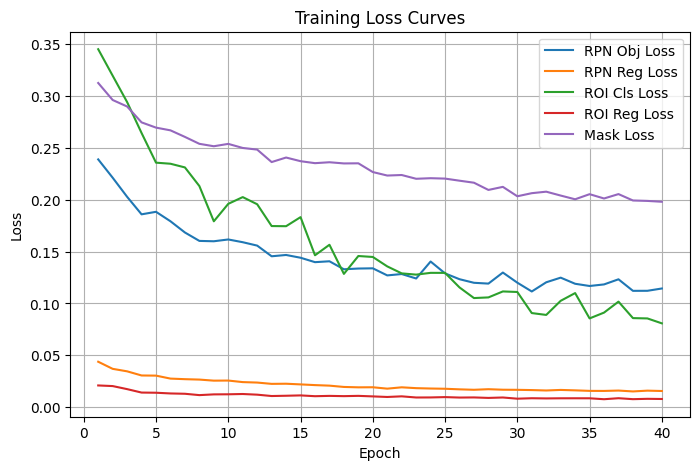

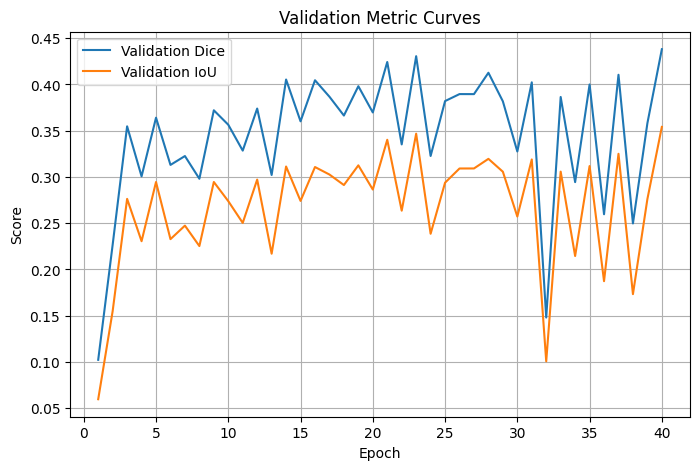

In [41]:
import matplotlib.pyplot as plt

def plot_maskrcnn_history(history):
    epochs = history["epoch"]

    # Plot 1: training losses
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["rpn_obj"], label="RPN Obj Loss")
    plt.plot(epochs, history["rpn_reg"], label="RPN Reg Loss")
    plt.plot(epochs, history["roi_cls"], label="ROI Cls Loss")
    plt.plot(epochs, history["roi_reg"], label="ROI Reg Loss")
    plt.plot(epochs, history["mask"], label="Mask Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss Curves")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot 2: validation metrics
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["val_dice"], label="Validation Dice")
    plt.plot(epochs, history["val_iou"], label="Validation IoU")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title("Validation Metric Curves")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_maskrcnn_history(history)

In [42]:
# ================================
# CELL TEST — Segmentation metrics
# ================================

ckpt = torch.load("best_maskrcnn.pth", map_location=device)

backbone.load_state_dict(ckpt["backbone"])
rpn.load_state_dict(ckpt["rpn"])
roi_head.load_state_dict(ckpt["roi"])
mask_head.load_state_dict(ckpt["mask"])

print("Loaded checkpoint from epoch:", ckpt.get("epoch", "N/A"))
print("Best VAL Dice:", ckpt.get("best_val_dice", "N/A"))

test_seg = eval_maskrcnn_seg(test_loader, score_thresh=0.02, det_nms=0.3)
print("TEST SEG:", test_seg)

Loaded checkpoint from epoch: 40
Best VAL Dice: 0.43810244604371285
TEST SEG: {'dice': 0.22743364409752237, 'iou': 0.16132358865541313, 'n_imgs': 264}


In [43]:
# ==========================================
# CELL EVALUATION — mAP50 / mAP50-95 / Recall
# ==========================================

import torch
import numpy as np

@torch.no_grad()
def collect_maskrcnn_detections(loader, score_thresh=0.02, det_nms=0.3):
    """
    Collect predicted boxes/scores and GT boxes for the whole dataset.
    Returns:
      preds: list of dicts {image_id, box, score}
      gts:   dict image_id -> Tensor (M,4)
    """
    backbone.eval(); rpn.eval(); roi_head.eval(); mask_head.eval()

    preds = []
    gts = {}
    img_id = 0

    for images, targets in loader:
        images = torch.stack(images).to(device)
        targets = [{"boxes": t["boxes"].to(device).float()} for t in targets]

        feat = backbone(images)
        B, C, Hf, Wf = feat.shape
        anchors = grid_anchors(Hf, Wf, STRIDE, base_anchors)

        obj_logits, bbox_deltas = rpn(feat)
        props = rpn_proposals(
            obj_logits, bbox_deltas, anchors, img_hw=(512, 512),
            num_anchors=base_anchors.shape[0],
            pre_nms_topk=3000, post_nms_topk=800,
            nms_thresh=0.7, score_thresh=0.01
        )

        for b in range(B):
            gt_boxes = targets[b]["boxes"]
            gts[img_id] = gt_boxes.clone()

            proposals = props[b]
            if proposals.numel() == 0:
                img_id += 1
                continue

            roi_feats = roi_pool_grid(feat[b], proposals, out_size=7, spatial_scale=1/STRIDE)
            roi_logits, roi_deltas = roi_head(roi_feats)
            probs = torch.softmax(roi_logits, dim=1)[:, 1]

            keep = torch.where(probs >= score_thresh)[0]
            if keep.numel() == 0:
                img_id += 1
                continue

            kept_props = proposals[keep]
            kept_scores = probs[keep]
            kept_deltas = roi_deltas[keep]

            det_boxes = decode_boxes(kept_props, kept_deltas)
            det_boxes = clip_boxes_to_image(det_boxes, 512, 512)

            keep2 = nms(det_boxes, kept_scores, iou_thresh=det_nms)
            det_boxes = det_boxes[keep2]
            det_scores = kept_scores[keep2]

            for i in range(det_boxes.shape[0]):
                preds.append({
                    "image_id": img_id,
                    "box": det_boxes[i].detach().cpu(),
                    "score": float(det_scores[i].detach().cpu()),
                })

            img_id += 1

    return preds, gts


def compute_ap_single_iou(preds, gts, iou_thr=0.5):
    """
    Compute AP for one class, one IoU threshold.
    preds: list of {image_id, box, score}
    gts:   dict image_id -> Tensor(M,4)
    """
    if len(gts) == 0:
        return 0.0, 0.0

    preds = sorted(preds, key=lambda x: x["score"], reverse=True)

    total_gt = sum(g.shape[0] for g in gts.values())
    if total_gt == 0:
        return 0.0, 0.0

    matched = {img_id: torch.zeros((gts[img_id].shape[0],), dtype=torch.bool) for img_id in gts}

    tp = np.zeros(len(preds), dtype=np.float32)
    fp = np.zeros(len(preds), dtype=np.float32)

    for i, pred in enumerate(preds):
        img_id = pred["image_id"]
        pred_box = pred["box"].unsqueeze(0)

        gt_boxes = gts[img_id]
        if gt_boxes.numel() == 0:
            fp[i] = 1.0
            continue

        ious = box_iou(pred_box.to(gt_boxes.device), gt_boxes).squeeze(0).detach().cpu()
        max_iou, j = ious.max(dim=0)

        if max_iou >= iou_thr and not matched[img_id][j]:
            tp[i] = 1.0
            matched[img_id][j] = True
        else:
            fp[i] = 1.0

    tp_cum = np.cumsum(tp)
    fp_cum = np.cumsum(fp)

    recalls = tp_cum / (total_gt + 1e-8)
    precisions = tp_cum / (tp_cum + fp_cum + 1e-8)

    # VOC-style interpolation
    mrec = np.concatenate(([0.0], recalls, [1.0]))
    mpre = np.concatenate(([0.0], precisions, [0.0]))

    for i in range(len(mpre) - 1, 0, -1):
        mpre[i - 1] = max(mpre[i - 1], mpre[i])

    idx = np.where(mrec[1:] != mrec[:-1])[0]
    ap = np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1])

    final_recall = recalls[-1] if len(recalls) > 0 else 0.0
    return float(ap), float(final_recall)


@torch.no_grad()
def eval_maskrcnn_detection_metrics(loader, score_thresh=0.02, det_nms=0.3):
    preds, gts = collect_maskrcnn_detections(loader, score_thresh=score_thresh, det_nms=det_nms)

    ap50, recall50 = compute_ap_single_iou(preds, gts, iou_thr=0.50)

    iou_thresholds = np.arange(0.50, 0.96, 0.05)
    aps = []
    for thr in iou_thresholds:
        ap_t, _ = compute_ap_single_iou(preds, gts, iou_thr=float(thr))
        aps.append(ap_t)

    map50_95 = float(np.mean(aps)) if len(aps) > 0 else 0.0

    return {
        "mAP50": float(ap50),
        "mAP50_95": float(map50_95),
        "recall": float(recall50),
        "n_preds": len(preds),
        "n_imgs": len(gts),
    }


# ---- Run on TEST ----
det_metrics = eval_maskrcnn_detection_metrics(test_loader, score_thresh=0.02, det_nms=0.3)
print("TEST DETECTION:", det_metrics)

TEST DETECTION: {'mAP50': 0.3370446145941206, 'mAP50_95': 0.1316681860278695, 'recall': 0.5681818127632141, 'n_preds': 1504, 'n_imgs': 264}


In [44]:
# ================================
# VISUALIZE MASK R-CNN RESULTS
# ================================

import matplotlib.pyplot as plt
import os

os.makedirs("/content/maskrcnn_vis", exist_ok=True)

@torch.no_grad()
def visualize_predictions(loader, num_images=5):

    backbone.eval()
    rpn.eval()
    roi_head.eval()
    mask_head.eval()

    shown = 0

    for images, targets in loader:

        images = torch.stack(images).to(device)

        targets = [{
            "boxes": t["boxes"].to(device).float(),
            "masks": t["masks"].to(device).float()
        } for t in targets]

        feat = backbone(images)

        B,C,Hf,Wf = feat.shape
        anchors = grid_anchors(Hf, Wf, STRIDE, base_anchors)

        obj_logits, bbox_deltas = rpn(feat)

        props = rpn_proposals(
            obj_logits,
            bbox_deltas,
            anchors,
            img_hw=(512,512),
            num_anchors=base_anchors.shape[0],
            pre_nms_topk=3000,
            post_nms_topk=800,
            nms_thresh=0.7,
            score_thresh=0.01
        )

        for b in range(B):

            if shown >= num_images:
                return

            img = images[b].cpu()[0]
            gt_mask = targets[b]["masks"][0].cpu()

            proposals = props[b]

            if proposals.numel()==0:
                continue

            roi_feats = roi_pool_grid(feat[b], proposals, out_size=7, spatial_scale=1/STRIDE)
            roi_logits, roi_deltas = roi_head(roi_feats)

            probs = torch.softmax(roi_logits,dim=1)[:,1]

            keep = torch.where(probs>=0.02)[0]

            if keep.numel()==0:
                continue

            proposals = proposals[keep]
            scores = probs[keep]
            deltas = roi_deltas[keep]

            boxes = decode_boxes(proposals,deltas)
            boxes = clip_boxes_to_image(boxes,512,512)

            keep2 = nms(boxes,scores,iou_thresh=0.3)
            boxes = boxes[keep2]

            mask_feats = roi_pool_grid(feat[b], boxes, out_size=14, spatial_scale=1/STRIDE)
            mask_logits = mask_head(mask_feats)

            mask_probs = torch.sigmoid(mask_logits[:,0])

            pred_full = torch.zeros((512,512),device=device)

            for i in range(boxes.shape[0]):
                pasted = paste_mask_to_image(mask_probs[i], boxes[i], H=512, W=512)
                pred_full = torch.maximum(pred_full,pasted)

            pred_mask = (pred_full>=0.5).float().cpu()

            fig,axs = plt.subplots(1,3,figsize=(12,4))

            axs[0].imshow(img,cmap="gray")
            axs[0].set_title("CT Image")

            axs[1].imshow(img,cmap="gray")
            axs[1].imshow(gt_mask,cmap="Greens",alpha=0.5)
            axs[1].set_title("Ground Truth")

            axs[2].imshow(img,cmap="gray")
            axs[2].imshow(pred_mask,cmap="Reds",alpha=0.5)
            axs[2].set_title("Prediction")

            for ax in axs:
                ax.axis("off")

            path = f"/content/maskrcnn_vis/sample_{shown}.png"
            plt.savefig(path, dpi=200, bbox_inches="tight")
            print("Saved:", path)

            plt.show()
            plt.close()

            print("Saved:",path)

            shown+=1

Saved: /content/maskrcnn_vis/sample_0.png


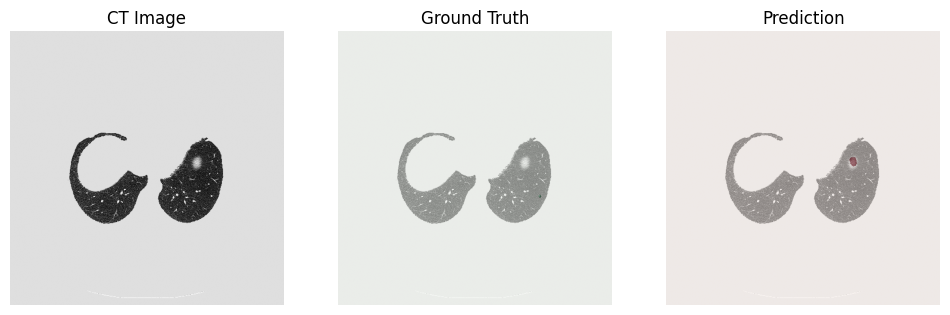

Saved: /content/maskrcnn_vis/sample_0.png
Saved: /content/maskrcnn_vis/sample_1.png


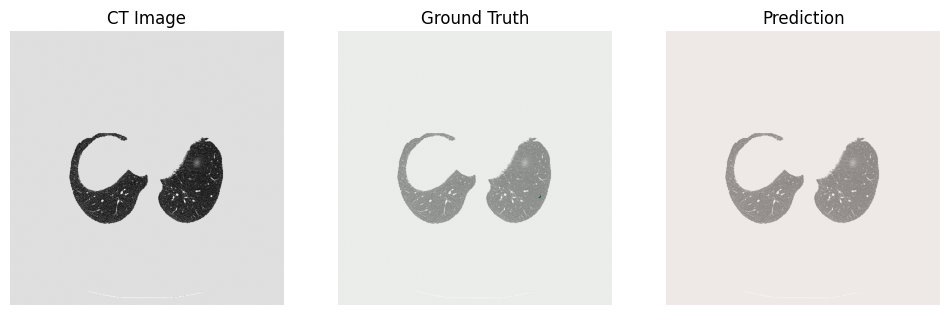

Saved: /content/maskrcnn_vis/sample_1.png
Saved: /content/maskrcnn_vis/sample_2.png


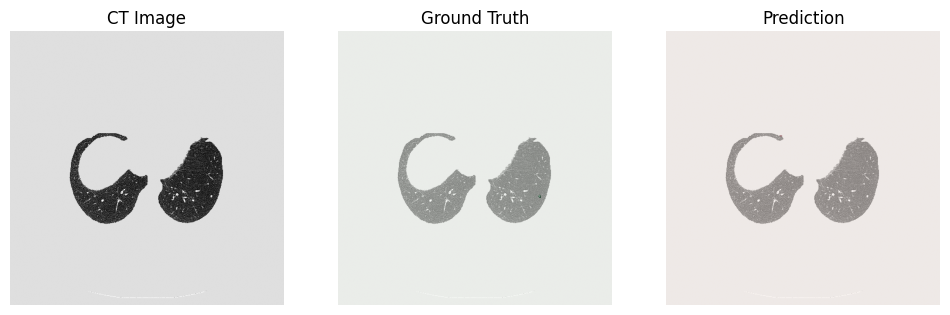

Saved: /content/maskrcnn_vis/sample_2.png
Saved: /content/maskrcnn_vis/sample_3.png


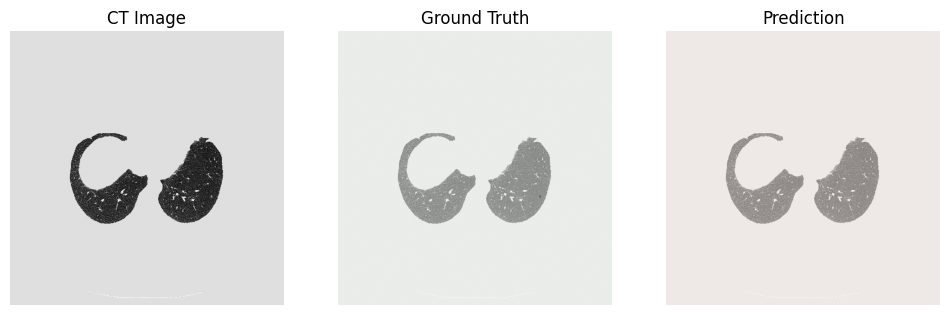

Saved: /content/maskrcnn_vis/sample_3.png
Saved: /content/maskrcnn_vis/sample_4.png


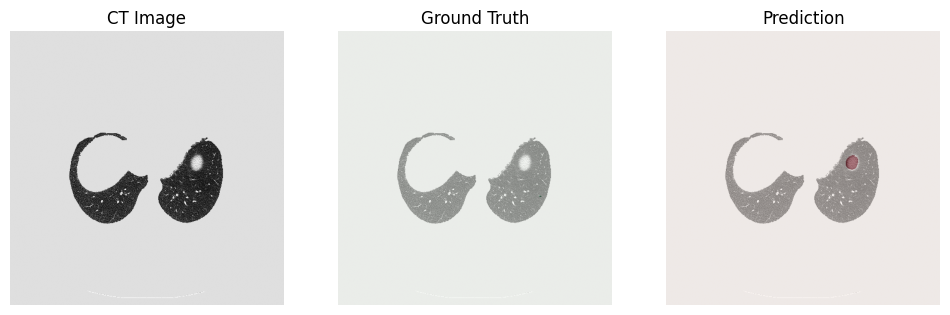

Saved: /content/maskrcnn_vis/sample_4.png
Saved: /content/maskrcnn_vis/sample_5.png


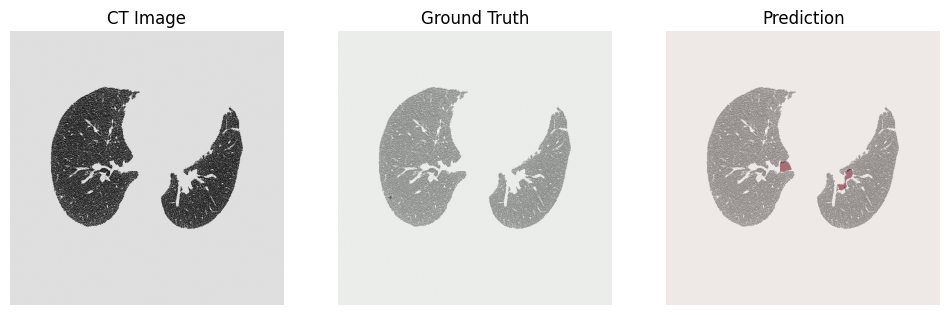

Saved: /content/maskrcnn_vis/sample_5.png


In [45]:
visualize_predictions(test_loader, num_images=6)